In [26]:
import numpy as np
from click.core import batch
from keras import datasets,layers,models,utils,preprocessing,Sequential
import matplotlib.pyplot as plt
from keras.src.layers import Dense,Flatten,Dropout,Conv2D,MaxPooling2D
from keras.preprocessing import image

In [27]:
batch_size=128
nb_classes=10
nb_epoch=25
img_rows,img_cols=32,32
img_channels=3
classes=['самолет', 'автомобиль', 'птица', 'кот', 'олень', 'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик']

In [28]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

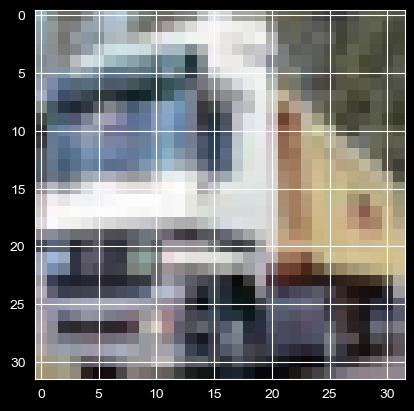

In [29]:
plt.imshow(x_train[1])
plt.show()

In [30]:
print("номер класса",y_train[1])
print("тип объекта")

номер класса [9]
тип объекта


In [31]:
x_train=x_train.astype('float32')
x_test=x_test.astype('float32')
x_train/=255
x_test/=255
y_train=utils.to_categorical(y_train, nb_classes)
y_test=utils.to_categorical(y_test, nb_classes)

In [32]:
model=Sequential()
model.add(Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same', input_shape=(32,32,3)))
model.add(Conv2D(32,kernel_size=(3, 3),activation='relu',padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Conv2D(64,kernel_size=(3, 3),activation='relu',padding='same'))
model.add(Conv2D(64,kernel_size=(3, 3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(nb_classes, activation='softmax'))
print(model.summary())


C:\Users\Flipper\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,676,842 (6.40 MB)

 Trainable params: 1,676,842 (6.40 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history=model.fit(x_train,y_train,batch_size=batch_size,epochs=nb_epoch,validation_split=0.1,shuffle=True,verbose=1)

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 56s 143ms/step - accuracy: 0.3953 - loss: 1.6416 - val_accuracy: 0.5470 - val_loss: 1.2604
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 78s 131ms/step - accuracy: 0.5553 - loss: 1.2426 - val_accuracy: 0.6242 - val_loss: 1.0794
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 46s 132ms/step - accuracy: 0.6183 - loss: 1.0744 - val_accuracy: 0.6706 - val_loss: 0.9399
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 47s 134ms/step - accuracy: 0.6578 - loss: 0.9585 - val_accuracy: 0.7122 - val_loss: 0.8362
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 47s 132ms/step - accuracy: 0.6948 - loss: 0.8677 - val_accuracy: 0.7290 - val_loss: 0.7824
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 50s 141ms/step - accuracy: 0.7187 - loss: 0.7995 - val_accuracy: 0.7430 - val_loss: 0.7390
Epoch 7/25
193/352 ━━━━━━━━━━━━━━━━━━━━ 22s 139ms/step - accuracy: 0.7393 - loss: 0.7475

In [ ]:
scores=model.evaluate(x_test,y_test,verbose=0)